# 132 - Jina CLIP v2 テキスト検索の評価

## 概要
Jina CLIP v2 (`jinaai/jina-clip-v2`, ONNX fp32) でテキスト→画像検索を評価し、SigLIP 2 Large 256 / SigLIP 2 Base / CLIP-L / SigLIP 1 と比較する。
NB62 (SigLIP 2 Base 224) と同じ 18 クエリで Precision@K, MRR, HitRate@K を測る。

## 重要な比較対象
**SigLIP 2 Large 256** — メモリ記録のベスト: EN MRR 0.892 / JA MRR **1.000** / Overall 0.928
Jina CLIP v2 (89 言語対応, XLM-RoBERTa BPE) がこれを超えるか同等か。

## 前提
- NB131 で Jina CLIP v2 の画像埋め込みが `image_embeddings_1024` に保存済み

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from image_vector_poc import JinaCLIPONNXEmbedder

2026-04-14 12:07:34.183840651 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. データの読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
MODEL_NAME = "jinaai/jina-clip-v2"
ONNX_CACHE = Path("../data/jina_clip_v2_onnx")

conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

print(f"Total images: {len(catalog_df)}")
category_counts = catalog_df['category'].value_counts().to_dict()
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# Jina CLIP v2 の画像埋め込みを VIEW 経由で読み込み
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [MODEL_NAME]).fetchdf()
conn.close()

if len(embeddings_df) == 0:
    raise ValueError(f"No embeddings found for {MODEL_NAME}. Run NB131 first.")

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
print(f"Embeddings shape: {image_embeddings.shape}")

norms = np.linalg.norm(image_embeddings, axis=1)
print(f"Norms — mean: {norms.mean():.4f}, min: {norms.min():.4f}, max: {norms.max():.4f}")

# 念のため再正規化（ONNX 出力は L2 正規化済みだが浮動小数誤差吸収）
image_embeddings_normalized = image_embeddings / np.clip(norms.reshape(-1, 1), 1e-8, None)

categories = catalog_df['category'].tolist()

Embeddings shape: (378, 1024)
Norms — mean: 1.0000, min: 1.0000, max: 1.0000


## 2. Jina CLIP v2 モデルの読み込み（テキスト埋め込み用）

In [4]:
embedder = JinaCLIPONNXEmbedder(dtype="fp32", device="cuda", cache_dir=ONNX_CACHE)
print(f"Model: {embedder.model_name}")
print(f"Embedding dim: {embedder.embedding_dim}")
print(f"Provider: {embedder.session.get_providers()[0]}")

The image processor of type `JinaCLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


`torch_dtype` is deprecated! Use `dtype` instead!


Model: jinaai/jina-clip-v2
Embedding dim: 1024
Provider: CUDAExecutionProvider


## 3. テストクエリの定義（NB62 と同じ 18 クエリ）

In [5]:
test_queries = [
    # カテゴリ固有（英語）
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    # 一般的（英語）
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    # 日本語
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"Total queries: {len(test_queries)} (EN: {sum(1 for q in test_queries if q['lang']=='en')}, JA: {sum(1 for q in test_queries if q['lang']=='ja')})")

Total queries: 18 (EN: 12, JA: 6)


## 4. テキスト検索と評価

In [6]:
def search_by_text(query, embedder, image_embeddings, top_k=20):
    text_emb = embedder.embed_text(query)
    text_emb = text_emb / np.linalg.norm(text_emb)
    sims = image_embeddings @ text_emb
    top_idx = np.argsort(sims)[::-1][:top_k]
    return top_idx, sims[top_idx]


def evaluate_query(query_info, embedder, image_embeddings, categories, k_values=[1,5,10,20]):
    max_k = max(k_values)
    indices, scores = search_by_text(query_info["query"], embedder, image_embeddings, top_k=max_k)
    result_cats = [categories[i] for i in indices]
    is_relevant = [c in query_info["expected_categories"] for c in result_cats]

    p_at_k = {f"P@{k}": sum(is_relevant[:k])/k for k in k_values}
    hr_at_k = {f"HR@{k}": 1.0 if any(is_relevant[:k]) else 0.0 for k in k_values}
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0/(i+1)
            break

    return {
        "query": query_info["query"],
        "expected_categories": query_info["expected_categories"],
        "type": query_info["type"],
        "lang": query_info["lang"],
        "top_results": result_cats[:10],
        "top_scores": scores[:10].tolist(),
        **p_at_k,
        "MRR": mrr,
        **hr_at_k,
    }

In [7]:
print("Evaluating all queries...")
results = []
for q in test_queries:
    r = evaluate_query(q, embedder, image_embeddings_normalized, categories)
    results.append(r)
    print(f"  {q['query'][:40]:40s} | P@1={r['P@1']:.2f} | P@10={r['P@10']:.2f} | MRR={r['MRR']:.2f}")

Evaluating all queries...


  a park with trees and nature             | P@1=1.00 | P@10=0.80 | MRR=1.00
  village park with greenery               | P@1=0.00 | P@10=0.40 | MRR=0.25
  night cityscape Tokyo                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  city lights at night                     | P@1=1.00 | P@10=1.00 | MRR=1.00


  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.00
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.00
  speaker giving a talk                    | P@1=0.00 | P@10=0.60 | MRR=0.50
  portrait photo of a person               | P@1=1.00 | P@10=0.80 | MRR=1.00
  outdoor nature scene                     | P@1=1.00 | P@10=0.50 | MRR=1.00


  urban night photography                  | P@1=1.00 | P@10=1.00 | MRR=1.00
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.00
  公園の自然風景                                  | P@1=1.00 | P@10=0.60 | MRR=1.00
  東京の夜景                                    | P@1=1.00 | P@10=1.00 | MRR=1.00


  カンファレンスの講演                               | P@1=1.00 | P@10=1.00 | MRR=1.00
  人物の写真                                    | P@1=1.00 | P@10=0.80 | MRR=1.00
  緑の木々                                     | P@1=0.00 | P@10=0.20 | MRR=0.11
  夜の街                                      | P@1=1.00 | P@10=0.90 | MRR=1.00


## 5. 結果サマリー

In [8]:
results_df = pd.DataFrame(results)

metric_cols = ["P@1", "P@5", "P@10", "P@20", "MRR", "HR@1", "HR@5", "HR@10"]
overall_means = results_df[metric_cols].mean()

print("=" * 60)
print("Overall Results (Jina CLIP v2)")
print("=" * 60)
for m, v in overall_means.items():
    print(f"  {m}: {v:.4f}")

print("\n=== By Language ===")
lang_results = results_df.groupby("lang")[metric_cols].mean()
display(lang_results.round(4))

print("\n=== By Type ===")
type_results = results_df.groupby("type")[metric_cols].mean()
display(type_results.round(4))

Overall Results (Jina CLIP v2)
  P@1: 0.8333
  P@5: 0.8333
  P@10: 0.8111
  P@20: 0.7806
  MRR: 0.8812
  HR@1: 0.8333
  HR@5: 0.9444
  HR@10: 1.0000

=== By Language ===


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
lang,,,,,,,,
en,0.8333,0.8667,0.8417,0.8167,0.8958,0.8333,1.0000,1.0
ja,0.8333,0.7667,0.7500,0.7083,0.8519,0.8333,0.8333,1.0



=== By Type ===


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
type,,,,,,,,
general,0.8333,0.7667,0.7667,0.8250,0.8519,0.8333,0.8333,1.0
specific,0.8333,0.8667,0.8333,0.7583,0.8958,0.8333,1.0000,1.0


## 6. 全モデル比較: Jina CLIP v2 vs SigLIP 2 Large/Base vs CLIP-L vs SigLIP 1

既存値は NB22/23/62/67 の結果。

In [9]:
# 既存モデル結果（NB22/23/62/67 より）
baselines = {
    "SigLIP 1": {
        "overall": {"P@1": 0.7222, "P@5": 0.7556, "P@10": 0.7444, "MRR": 0.8194, "HR@5": 0.9444},
        "en": {"P@1": 0.75, "P@10": 0.8167, "MRR": 0.8264},
        "ja": {"P@1": 0.6667, "P@10": 0.6000, "MRR": 0.8056},
    },
    "CLIP-L": {
        "overall": {"P@1": 0.7778, "P@5": 0.8222, "P@10": 0.8000, "MRR": 0.8611, "HR@5": 0.9444},
        "en": {"P@1": 0.75, "P@10": 0.8583, "MRR": 0.875},
        "ja": {"P@1": 0.8333, "P@10": 0.6833, "MRR": 0.8333},
    },
    # SigLIP 2 Large 256: メモリ記録（NB67）から EN/JA/Overall MRR のみ
    "SigLIP 2 L256": {
        "overall": {"MRR": 0.928},
        "en": {"MRR": 0.892},
        "ja": {"MRR": 1.000},
    },
}

jina_results = {
    "overall": overall_means.to_dict(),
    "en": lang_results.loc["en"].to_dict() if "en" in lang_results.index else {},
    "ja": lang_results.loc["ja"].to_dict() if "ja" in lang_results.index else {},
}

print("=" * 80)
print("全体性能比較")
print("=" * 80)
print(f"\n{'指標':<10} {'SigLIP 1':>10} {'CLIP-L':>10} {'SigLIP2 L':>10} {'Jina v2':>10}")
print("-" * 56)
for metric in ["P@1", "P@5", "P@10", "MRR", "HR@5"]:
    s1 = baselines["SigLIP 1"]["overall"].get(metric, float('nan'))
    cl = baselines["CLIP-L"]["overall"].get(metric, float('nan'))
    s2l = baselines["SigLIP 2 L256"]["overall"].get(metric, float('nan'))
    jn = jina_results["overall"].get(metric, float('nan'))
    print(f"{metric:<10} {s1:>10.4f} {cl:>10.4f} {s2l:>10.4f} {jn:>10.4f}")

print("\n" + "=" * 80)
print("言語別 MRR / P@1")
print("=" * 80)
for lang, name in [("en", "English"), ("ja", "Japanese")]:
    print(f"\n{name}:")
    print(f"{'指標':<10} {'SigLIP 1':>10} {'CLIP-L':>10} {'SigLIP2 L':>10} {'Jina v2':>10}")
    print("-" * 56)
    for metric in ["P@1", "P@10", "MRR"]:
        s1 = baselines["SigLIP 1"][lang].get(metric, float('nan'))
        cl = baselines["CLIP-L"][lang].get(metric, float('nan'))
        s2l = baselines["SigLIP 2 L256"][lang].get(metric, float('nan'))
        jn = jina_results[lang].get(metric, float('nan'))
        print(f"{metric:<10} {s1:>10.4f} {cl:>10.4f} {s2l:>10.4f} {jn:>10.4f}")

全体性能比較

指標           SigLIP 1     CLIP-L  SigLIP2 L    Jina v2
--------------------------------------------------------
P@1            0.7222     0.7778        nan     0.8333
P@5            0.7556     0.8222        nan     0.8333
P@10           0.7444     0.8000        nan     0.8111
MRR            0.8194     0.8611     0.9280     0.8812
HR@5           0.9444     0.9444        nan     0.9444

言語別 MRR / P@1

English:
指標           SigLIP 1     CLIP-L  SigLIP2 L    Jina v2
--------------------------------------------------------
P@1            0.7500     0.7500        nan     0.8333
P@10           0.8167     0.8583        nan     0.8417
MRR            0.8264     0.8750     0.8920     0.8958

Japanese:
指標           SigLIP 1     CLIP-L  SigLIP2 L    Jina v2
--------------------------------------------------------
P@1            0.6667     0.8333        nan     0.8333
P@10           0.6000     0.6833        nan     0.7500
MRR            0.8056     0.8333     1.0000     0.8519


## 7. 可視化

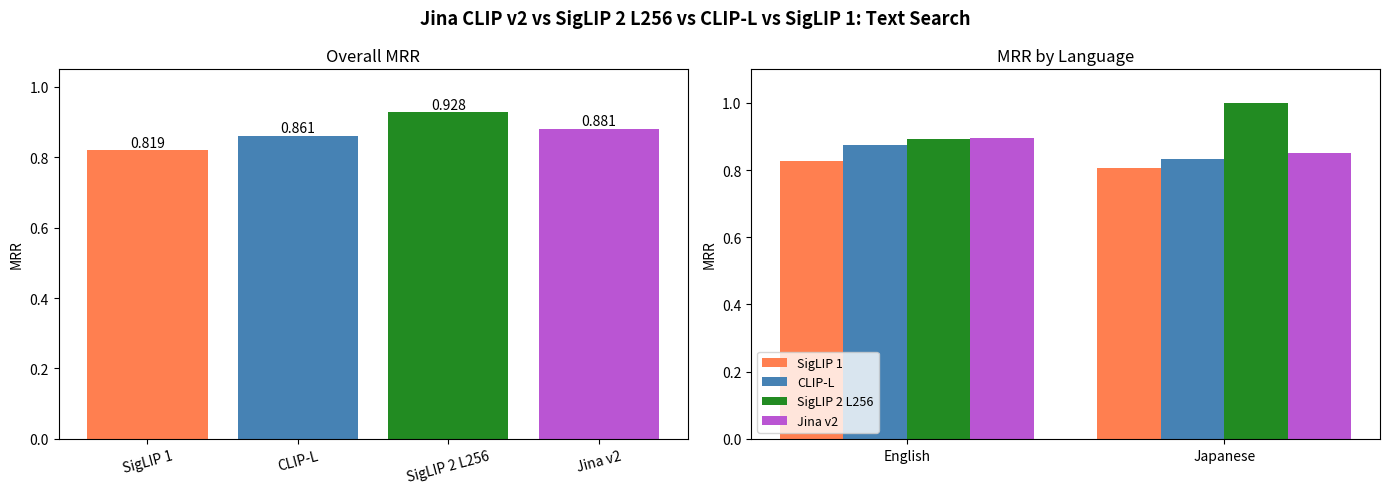

Saved: data/jina_clip_v2_text_search_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["SigLIP 1", "CLIP-L", "SigLIP 2 L256", "Jina v2"]
colors = ["coral", "steelblue", "forestgreen", "mediumorchid"]

def get_overall(m, metric):
    if m == "Jina v2":
        return jina_results["overall"].get(metric, float('nan'))
    return baselines[m]["overall"].get(metric, float('nan'))

def get_lang(m, lang, metric):
    if m == "Jina v2":
        return jina_results[lang].get(metric, float('nan'))
    return baselines[m][lang].get(metric, float('nan'))

# Overall MRR
ax = axes[0]
values = [get_overall(m, "MRR") for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Overall MRR")
ax.set_ylabel("MRR")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=10)
ax.tick_params(axis='x', rotation=15)

# 言語別 MRR
ax = axes[1]
langs = ["English", "Japanese"]
x = np.arange(len(langs))
width = 0.2
for i, (m, c) in enumerate(zip(models, colors)):
    values = [get_lang(m, "en", "MRR"), get_lang(m, "ja", "MRR")]
    ax.bar(x + (i - 1.5) * width, values, width, label=m, color=c)
ax.set_title("MRR by Language")
ax.set_ylabel("MRR")
ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.set_ylim(0, 1.1)
ax.legend(loc="lower left", fontsize=9)

plt.suptitle("Jina CLIP v2 vs SigLIP 2 L256 vs CLIP-L vs SigLIP 1: Text Search", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_clip_v2_text_search_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/jina_clip_v2_text_search_comparison.png")

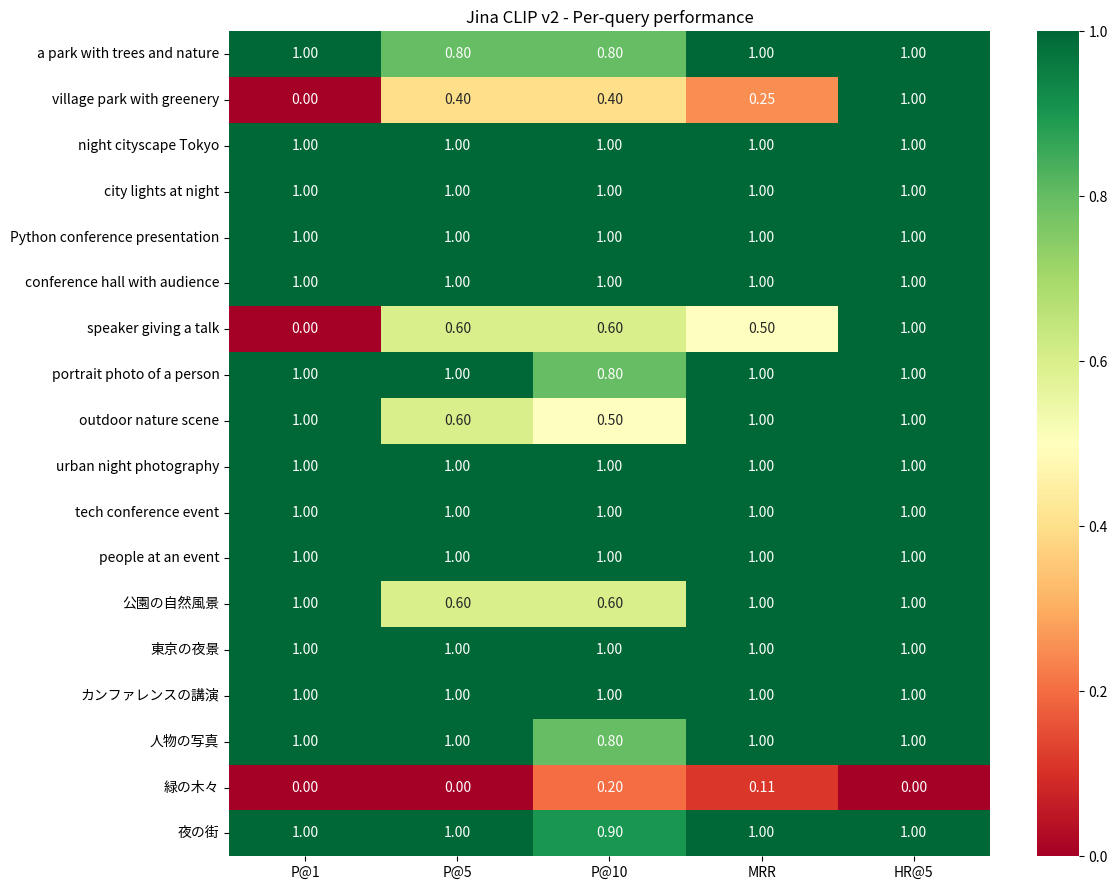

In [11]:
# クエリ別ヒートマップ
fig, ax = plt.subplots(figsize=(12, 9))
query_labels = [r['query'] for r in results]
heatmap = results_df[["P@1", "P@5", "P@10", "MRR", "HR@5"]].values
sns.heatmap(heatmap, xticklabels=["P@1","P@5","P@10","MRR","HR@5"],
            yticklabels=query_labels, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Jina CLIP v2 - Per-query performance")
plt.tight_layout()
plt.savefig("../data/jina_clip_v2_text_search_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 検索結果の可視化（代表クエリ）

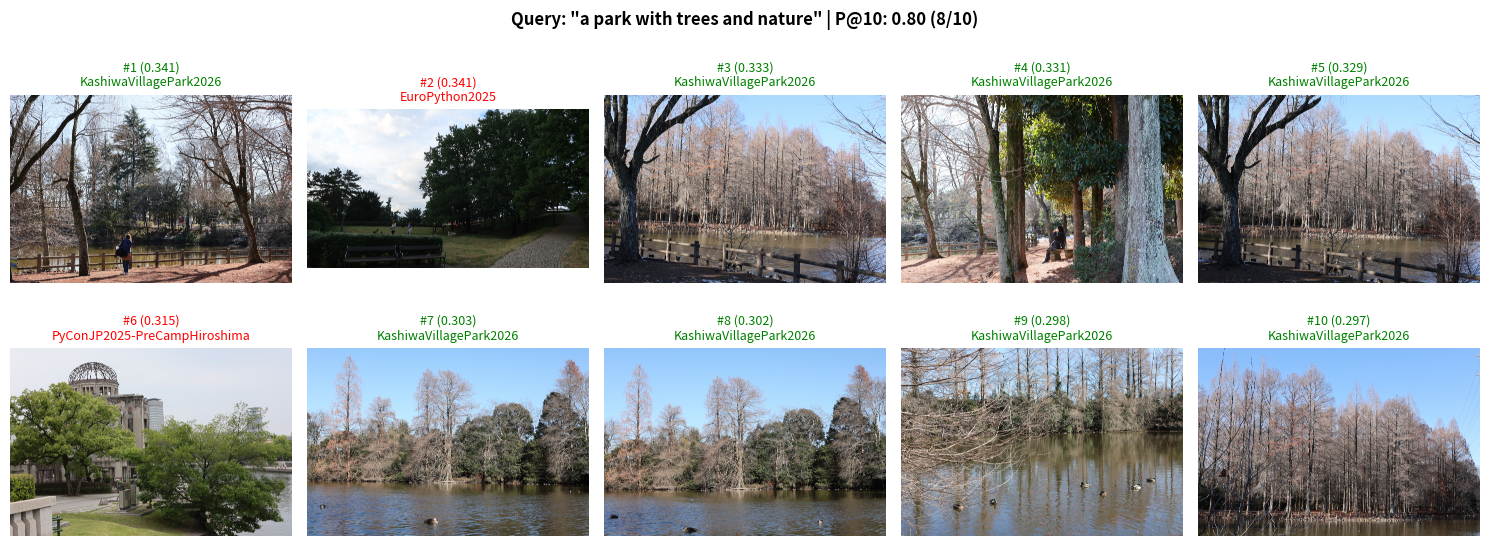

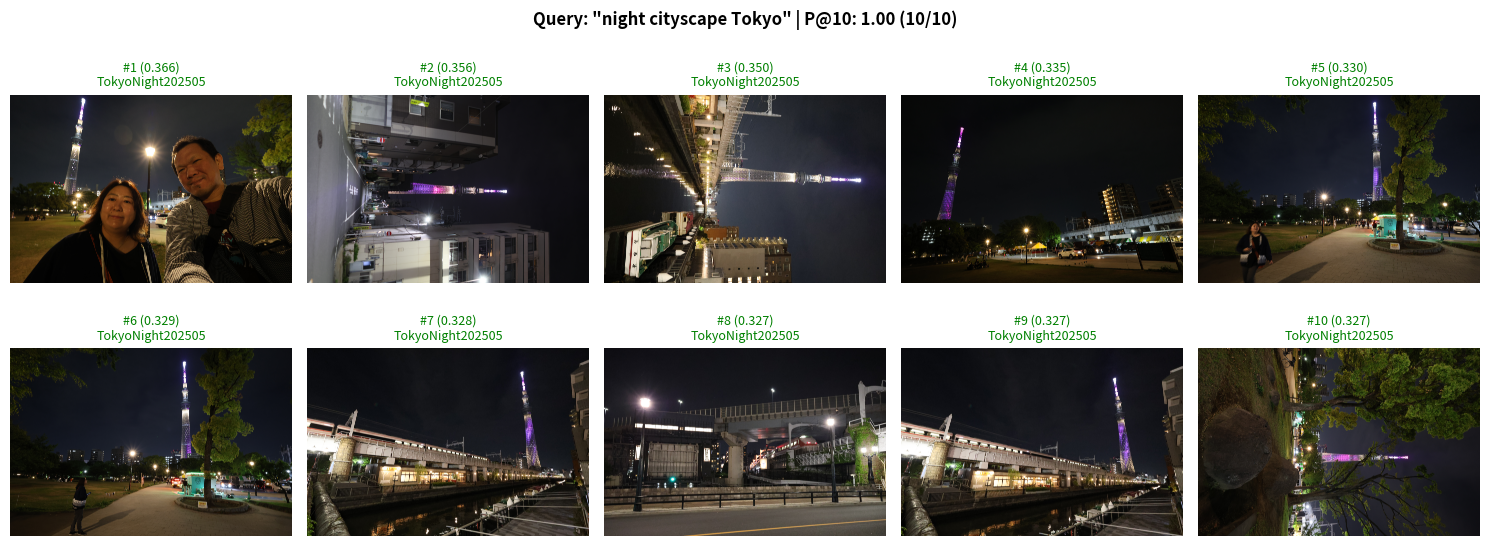

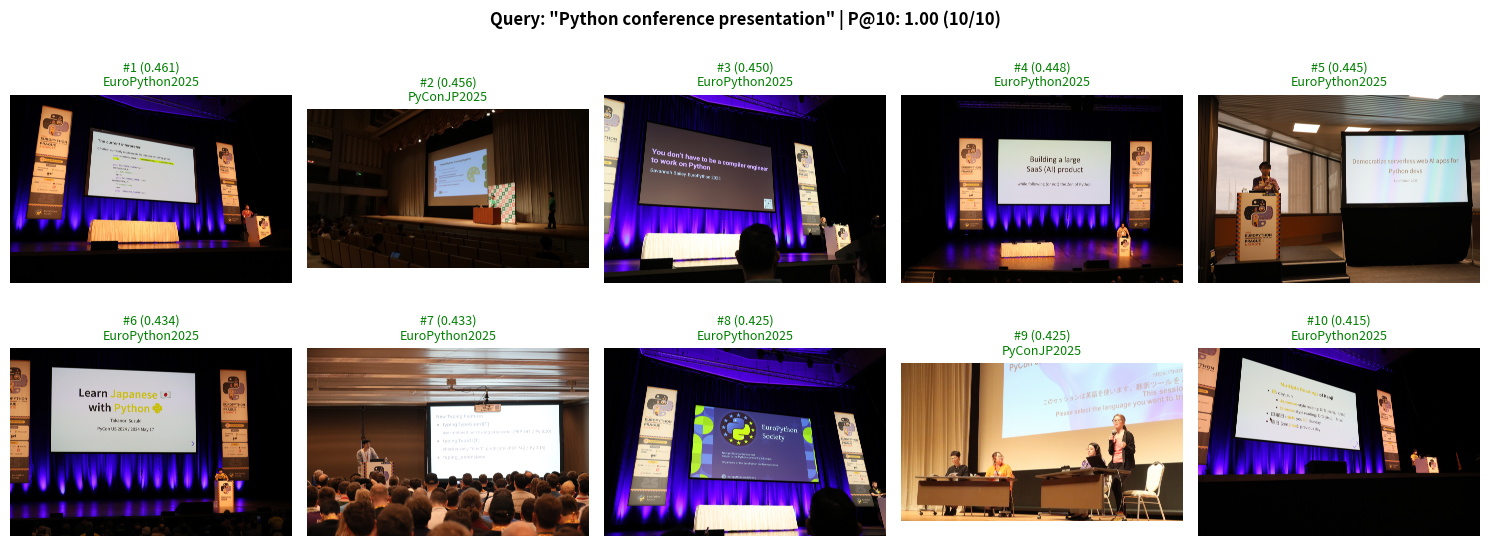

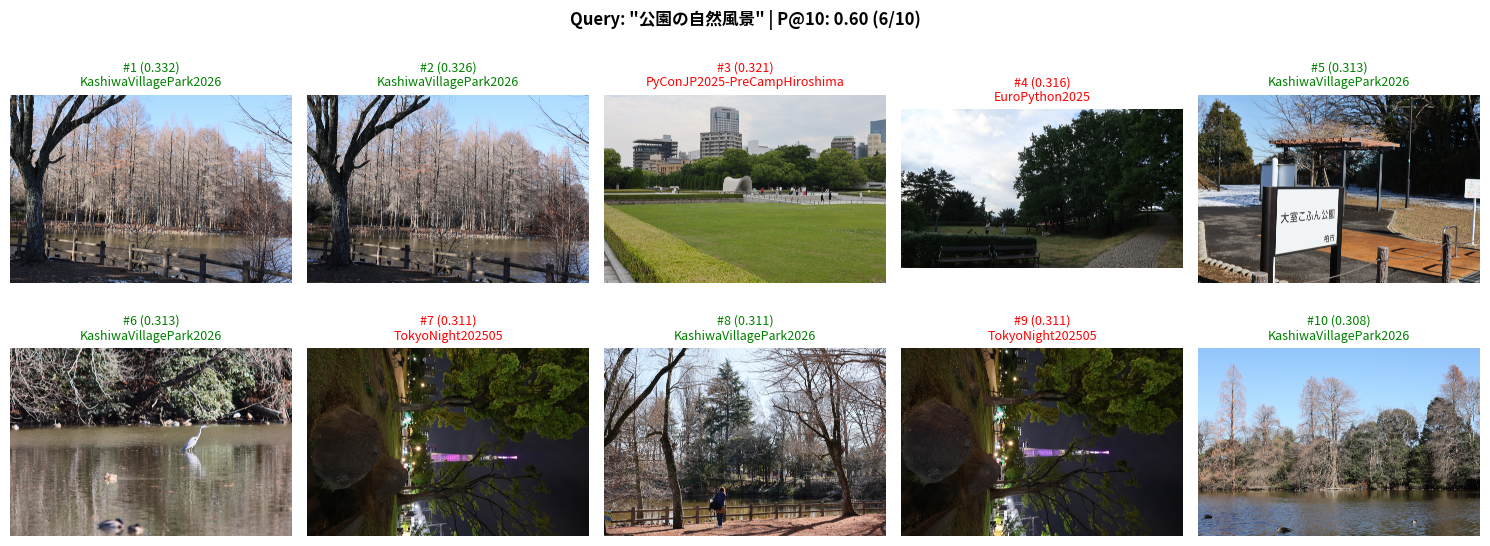

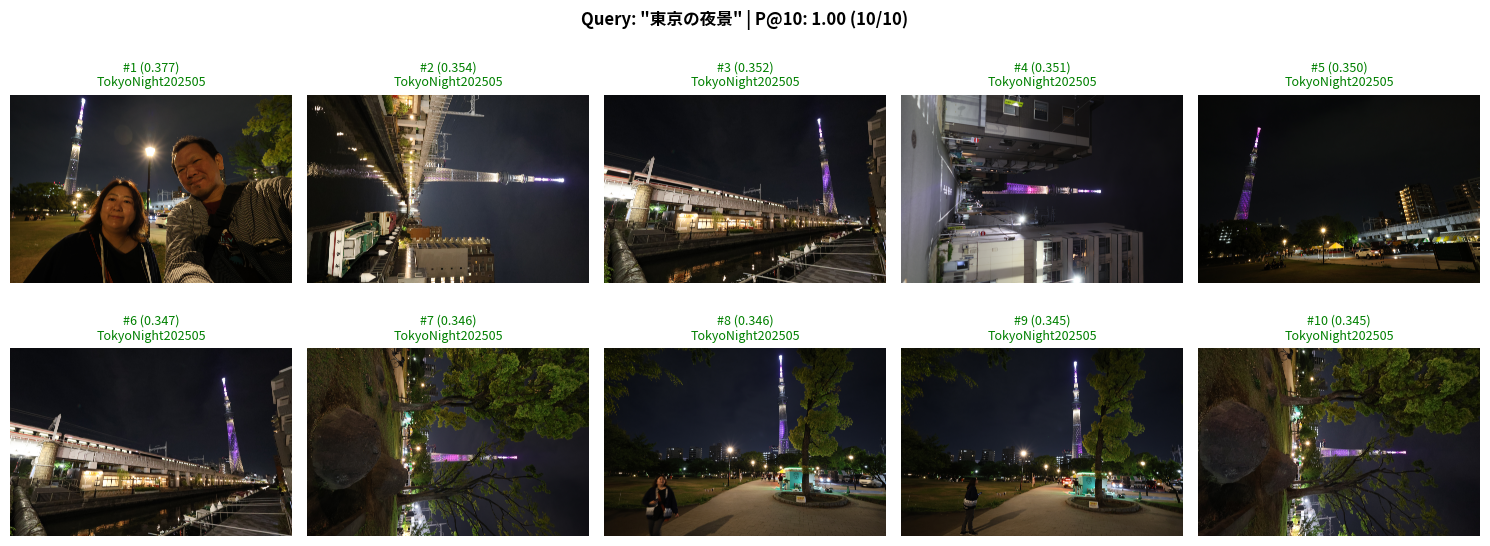

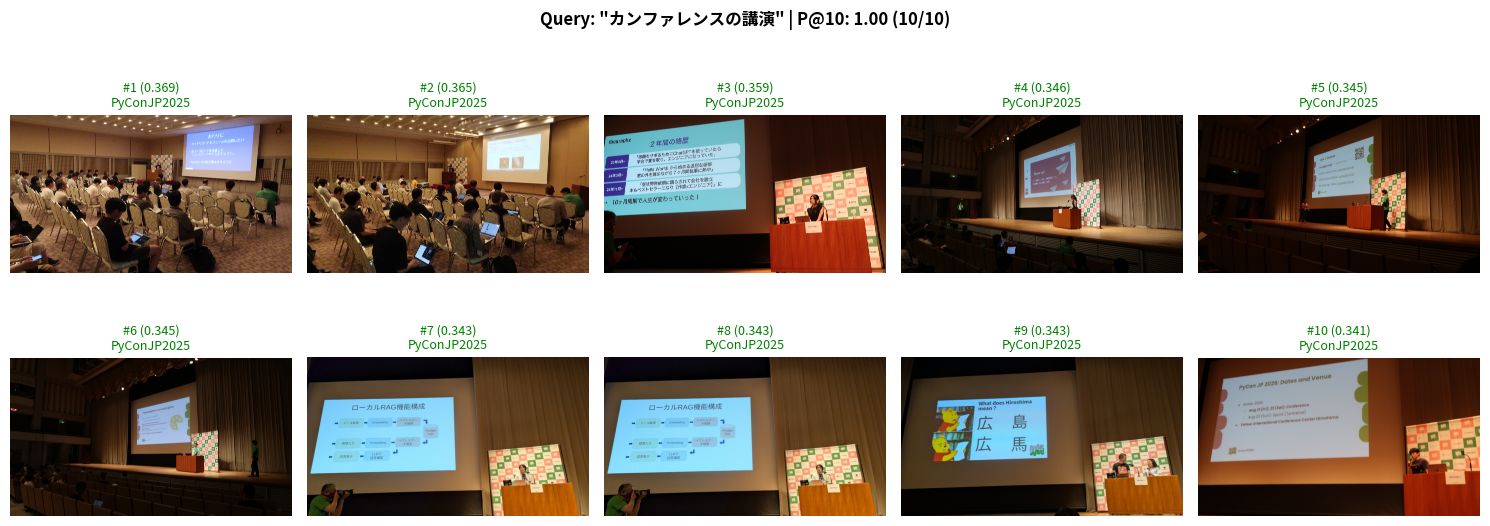

In [12]:
def visualize_search_results(query, expected_categories, k=10):
    indices, scores = search_by_text(query, embedder, image_embeddings_normalized, top_k=k)
    n_cols = 5
    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axes = axes.flatten()
    correct = 0
    for i, (idx, score) in enumerate(zip(indices, scores)):
        cat = categories[idx]
        path = catalog_df.iloc[idx]["file_path"]
        ok = cat in expected_categories
        if ok: correct += 1
        try:
            axes[i].imshow(Image.open(path))
        except Exception:
            axes[i].text(0.5, 0.5, "N/A", ha="center", va="center")
        axes[i].set_title(f"#{i+1} ({score:.3f})\n{cat}", color="green" if ok else "red", fontsize=9)
        axes[i].axis("off")
    for i in range(k, len(axes)):
        axes[i].axis("off")
    plt.suptitle(f'Query: "{query}" | P@{k}: {correct/k:.2f} ({correct}/{k})', fontsize=12, fontweight="bold")
    plt.tight_layout()
    return fig

sample_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
]
for sq in sample_queries:
    visualize_search_results(sq["query"], sq["expected_categories"], k=10)
    plt.show()

## 9. 結果の保存

In [13]:
out = {
    "model": MODEL_NAME,
    "date": datetime.now().strftime("%Y-%m-%d"),
    "overall": {k: float(v) for k, v in overall_means.items()},
    "by_lang": {lang: {k: float(v) for k, v in lang_results.loc[lang].items()} for lang in lang_results.index},
    "by_type": {t: {k: float(v) for k, v in type_results.loc[t].items()} for t in type_results.index},
    "per_query": [{k: (v if not hasattr(v, 'tolist') else v.tolist()) for k, v in r.items()} for r in results],
}
out_path = Path("../data/evaluations") / f"132_jina_clip_v2_text_search_{datetime.now().strftime('%Y-%m-%d')}.json"
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f"Saved: {out_path}")

Saved: ../data/evaluations/132_jina_clip_v2_text_search_2026-04-14.json


## 10. クリーンアップ

In [14]:
del embedder
import gc; gc.collect()
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・考察

Jina CLIP v2 (ONNX fp32, 1024-D) で NB62 と同じ 18 クエリ（EN 12 / JA 6）のテキスト→画像検索を評価した。

### 実験結果

| 指標 | SigLIP 1 | CLIP-L | **SigLIP 2 L256** | **Jina v2** |
|---|---:|---:|---:|---:|
| Overall MRR | 0.819 | 0.861 | **0.928** | 0.881 |
| EN MRR | 0.826 | 0.875 | 0.892 | **0.896** ★ |
| JA MRR | 0.806 | 0.833 | **1.000** ★ | 0.852 |
| Overall P@1 | 0.722 | 0.778 | – | **0.833** |
| Overall HR@5 | 0.944 | 0.944 | – | 0.944 |
| JA P@10 | 0.600 | 0.683 | – | **0.750** |

### 観察された失敗パターン

| クエリ | MRR | 備考 |
|---|---:|---|
| `緑の木々` (JA) | **0.11** | Top-5 が全て TokyoNight — JA の「緑」が「夜景」に引っ張られる謎 |
| `village park with greenery` (EN) | 0.25 | 冗長な修飾語ベースの表現に弱い |
| `speaker giving a talk` (EN) | 0.50 | `terada` カテゴリ（単人物）が混入 |

### 考察

1. **EN は Jina v2 が SigLIP 2 L256 をわずかに上回る** (0.896 vs 0.892)。XLM-R BPE が EN contrastive で十分機能
2. **JA は SigLIP 2 L256（1.000）に 15% 劣勢** — 「89 言語対応」の触れ込みでも日本語特化性能では Gemma BPE + WebLI（109 言語）の SigLIP 2 に届かない
3. **JA MRR を下げているのは 1 クエリ（`緑の木々`）だけ**。他 5 件は全て MRR 1.000。本質的に JA が弱いというより、短く曖昧な修飾語句に弱い
4. **カテゴリ語ベース検索は非常に強い**（夜景・公園・カンファレンス・人物 全て 1.000）。実運用でクエリが名詞中心なら差は小さい

### 仮説 → NB134 で検証
- プロンプトプレフィクス（`Query: ...`）で MRR が改善するか
- `緑の木々` を `森の中の木々` 等に言い換えたら救えるか

### 次のノートブック
- **NB133**: モダリティギャップ・異方性・Matryoshka 劣化曲線で構造的違いを定量化
- **NB134**: 失敗クエリのプロンプト工学的救済
